In [5]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    classification_report
)

from imblearn.over_sampling import SMOTE
import joblib, os, json

# Imports for modeling  
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


sns.set(style="whitegrid")


In [6]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path(r"C:\Users\ACER\Desktop\All Projects\automobile-predictive-failure\vehicle_failure_detection.csv")

dataset = pd.read_csv(DATA_PATH)

assert len(dataset) > 0, "Dataset is empty"
assert "Target" in dataset.columns, "Target column missing"

raw_dataset = dataset.copy()

print("✅ Dataset loaded from:", DATA_PATH.resolve())
print("Shape:", dataset.shape)
dataset.head()


✅ Dataset loaded from: C:\Users\ACER\Desktop\All Projects\automobile-predictive-failure\vehicle_failure_detection.csv
Shape: (10000, 9)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [7]:
#Drop non-informative columns
drop_cols = [c for c in ["UDI", "Product ID"] if c in dataset.columns]
dataset = dataset.drop(columns=drop_cols)

print("After dropping IDs:", dataset.shape)


After dropping IDs: (10000, 7)


In [8]:
# A) Project constants (LOCK)
TARGET_COL = "Target"

FEATURES = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Sanity checks
missing = [c for c in FEATURES + [TARGET_COL] if c not in dataset.columns]
assert not missing, f"Missing columns: {missing}"

print("✅ Locked FEATURES:", FEATURES)


✅ Locked FEATURES: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [9]:
# B) Build X, y (ONLY from locked FEATURES)
X = dataset[FEATURES].copy()
y = dataset[TARGET_COL].astype(int).copy()

print("X shape:", X.shape, "| y shape:", y.shape)
print("Class balance:\n", y.value_counts(normalize=True))


X shape: (10000, 6) | y shape: (10000,)
Class balance:
 Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [10]:
# C) Encode Type safely (LabelEncoder) + keep encoder
from sklearn.preprocessing import LabelEncoder

type_encoder = LabelEncoder()
X["Type"] = type_encoder.fit_transform(X["Type"].astype(str))

print("Type classes:", list(type_encoder.classes_))


Type classes: ['H', 'L', 'M']


In [11]:
#Freeze feature set (prevents 6 vs 8 mismatch bugs)
TARGET_COL = "Target"

FEATURES = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Safety checks
missing = [c for c in FEATURES + [TARGET_COL] if c not in dataset.columns]
assert not missing, f"Missing columns in dataset: {missing}"

# Always build X and y from these fixed columns only
X = dataset[FEATURES].copy()
y = dataset[TARGET_COL].astype(int).copy()

print("X shape:", X.shape, "| y shape:", y.shape)
print("Feature columns locked:", FEATURES)


X shape: (10000, 6) | y shape: (10000,)
Feature columns locked: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [12]:
# Cell 5 — Overview
print("Dataset dtypes:")
display(dataset.dtypes)

print("\nSummary stats:")
display(dataset[FEATURES + [TARGET_COL]].describe().T)


Dataset dtypes:


Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
dtype: object


Summary stats:


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Target,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0


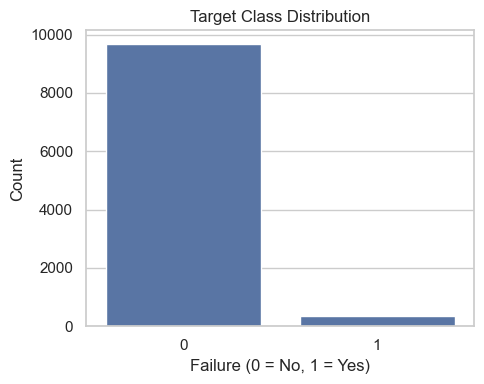

Counts:
 Target
0    9661
1     339
Name: count, dtype: int64

Proportions:
 Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Imbalance Ratio (0:1) ≈ 28.50:1


In [13]:
#EDA: TARGET DISTRIBUTION

plt.figure(figsize=(5, 4))
sns.countplot(x="Target", data=dataset)
plt.title("Target Class Distribution")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

counts = dataset["Target"].value_counts()
props = dataset["Target"].value_counts(normalize=True)

print("Counts:\n", counts)
print("\nProportions:\n", props)

imbalance_ratio = counts[0] / max(counts.get(1, 1), 1)
print(f"\nImbalance Ratio (0:1) ≈ {imbalance_ratio:.2f}:1")


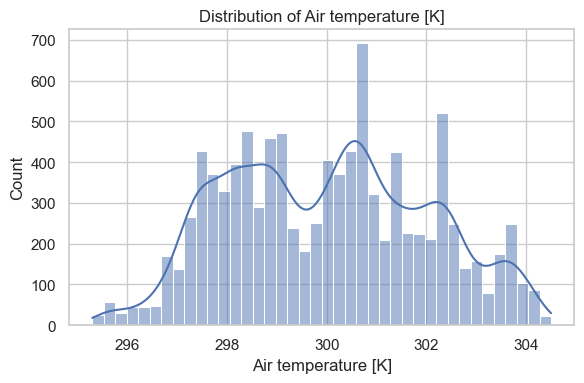

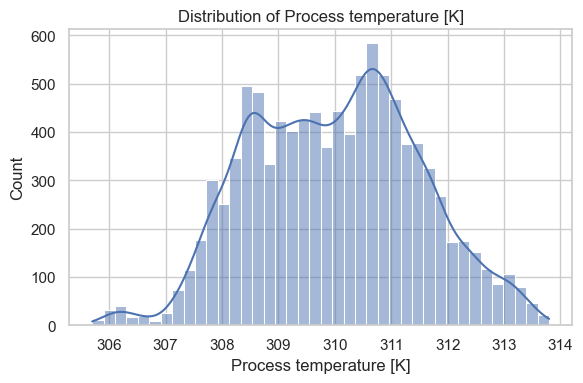

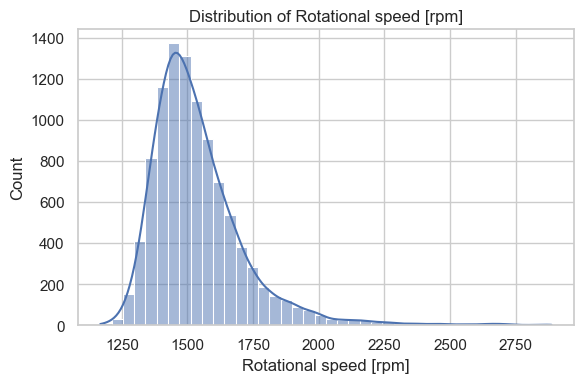

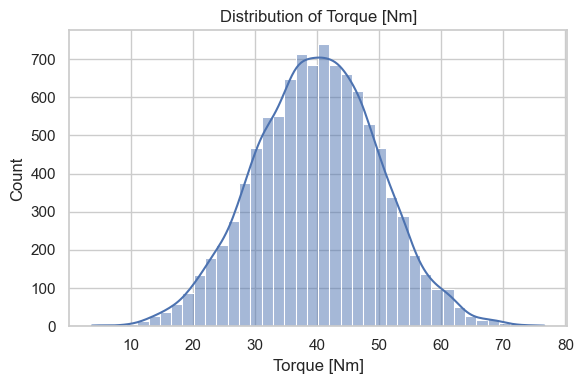

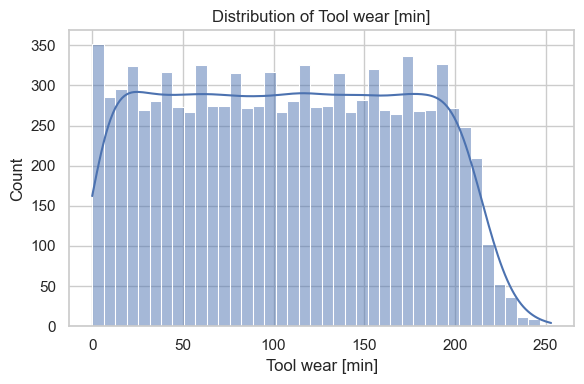

In [14]:
# EDA: Univariate distributions
# Goal: Understand each feature’s range, skewness, tails, and potential outliers.
# Histogram shows frequency; KDE shows a smoothed density curve.

num_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=dataset,
        x=col,
        bins=40,
        kde=True
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


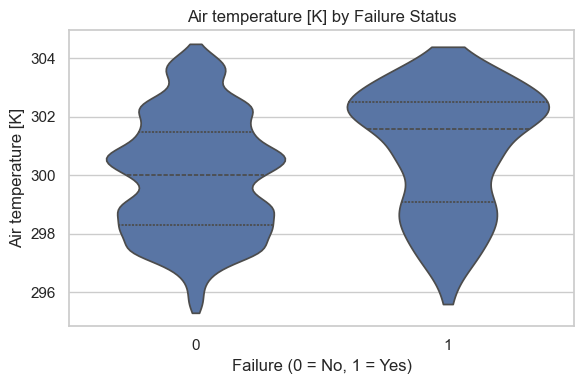

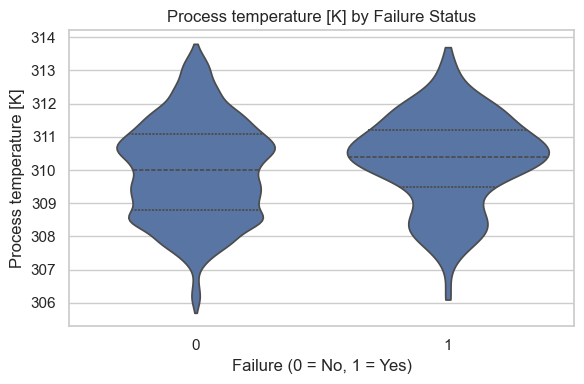

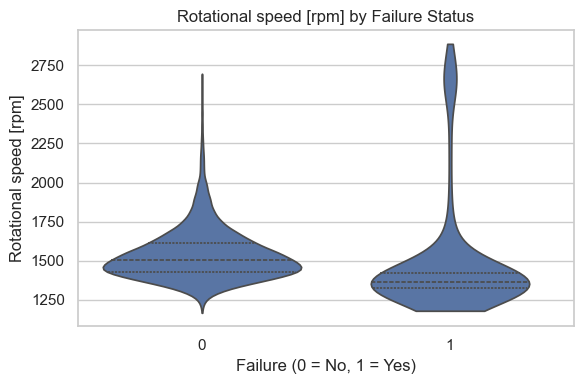

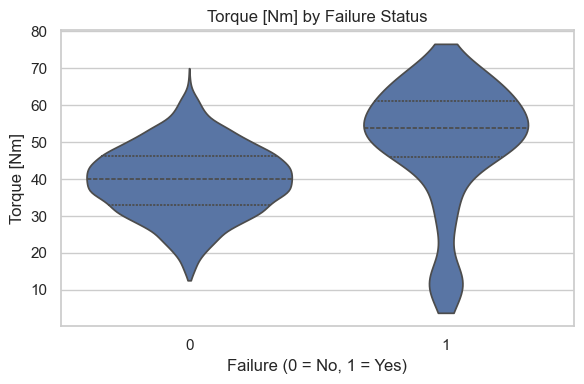

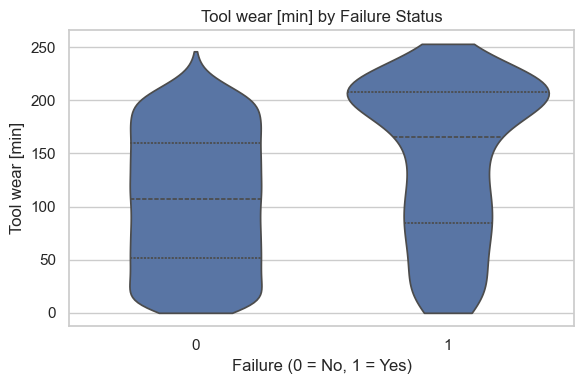

In [15]:
# EDA: Feature distribution by Target
# Goal: Compare feature behavior for failures vs non-failures.
# Violin plot shows the full distribution; quartile lines summarize median/IQR.

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        x="Target",
        y=col,
        data=dataset,
        inner="quartile",
        cut=0
    )
    plt.title(f"{col} by Failure Status")
    plt.xlabel("Failure (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


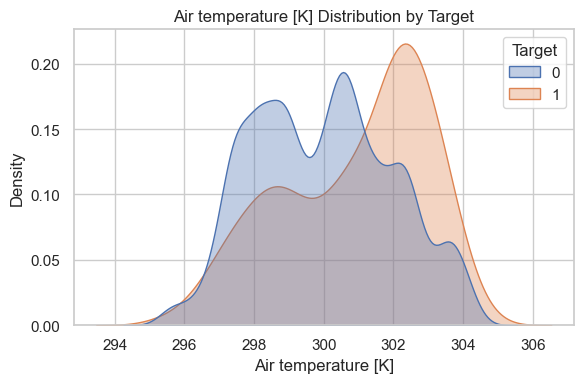

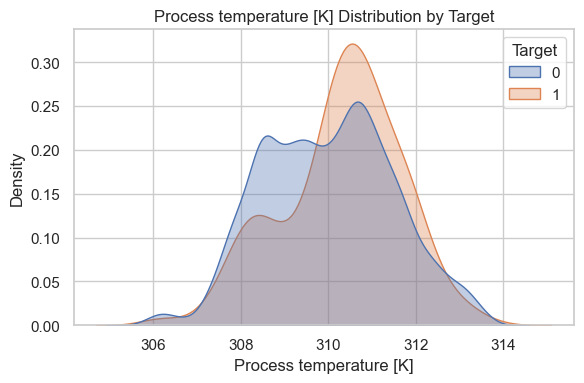

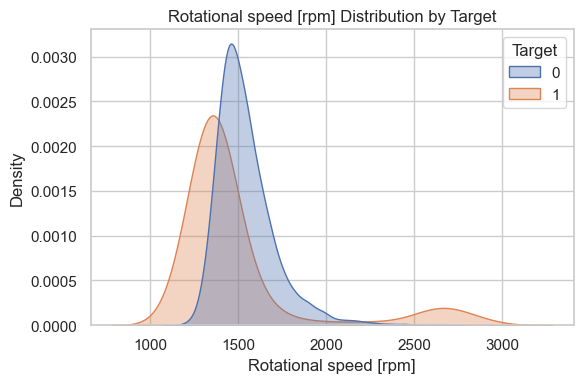

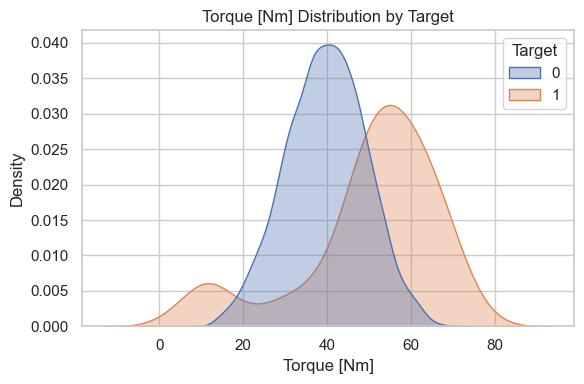

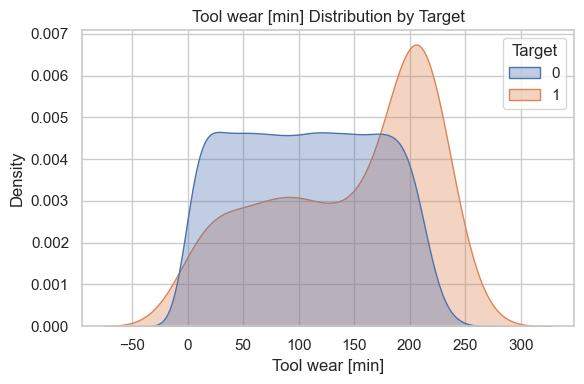

In [16]:
# EDA: KDE plots (feature vs Target)
# Goal: See if the distribution of each feature is different for failures (1) vs non-failures (0).
# If the curves are clearly separated, that feature is likely predictive.

for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(
        data=dataset,
        x=col,
        hue="Target",
        fill=True,
        common_norm=False,   # each class normalized separately (better for imbalance)
        alpha=0.35,
        bw_adjust=1.1        # slightly smoother KDE (reduces noisy wiggles)
    )
    plt.title(f"{col} Distribution by Target")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


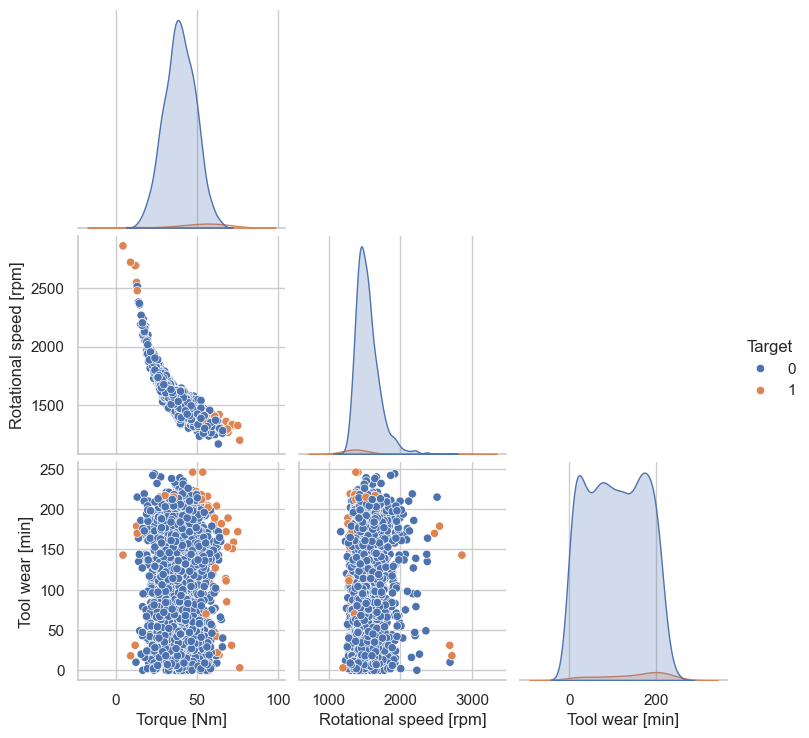

In [17]:
# EDA: Pairplot (feature interactions)
# Goal: Visualize how pairs of features behave together and whether failures occupy a different region.
# Pairplots can be slow, so we sample for speed + readability.

pair_cols = ["Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]", "Target"]

sample_df = dataset[pair_cols].sample(
    n=min(2000, len(dataset)),
    random_state=42
)

sns.pairplot(sample_df, hue="Target", diag_kind="kde", corner=True)
plt.show()


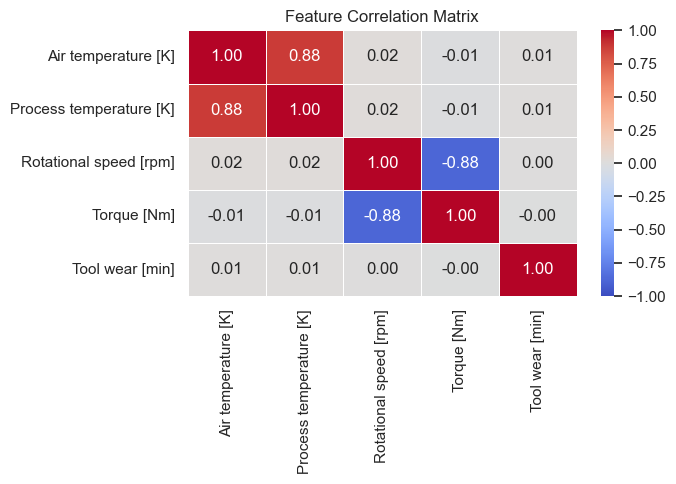

In [18]:
# EDA: Correlation Matrix (numeric)
# Goal: Identify highly correlated features (redundancy) and strong relationships.
# Note: Correlation is linear association, not causation.

corr = dataset[num_features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [19]:
# Cell 13 — Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train target ratio:\n", y_train.value_counts(normalize=True))
print("Test target ratio:\n", y_test.value_counts(normalize=True))


Train: (7000, 6) | Test: (3000, 6)
Train target ratio:
 Target
0    0.966143
1    0.033857
Name: proportion, dtype: float64
Test target ratio:
 Target
0    0.966
1    0.034
Name: proportion, dtype: float64


In [20]:
# Cell 14 — Outlier capping (fit on TRAIN only, apply to train/test)
def fit_iqr_bounds(df, cols, factor=1.5):
    bounds = {}
    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        bounds[c] = (q1 - factor*iqr, q3 + factor*iqr)
    return bounds

def apply_iqr_bounds(df, bounds):
    df = df.copy()
    for c, (lo, hi) in bounds.items():
        df[c] = df[c].clip(lo, hi)
    return df

num_features = [c for c in FEATURES if c != "Type"]
iqr_bounds = fit_iqr_bounds(X_train, num_features, factor=1.5)

X_train = apply_iqr_bounds(X_train, iqr_bounds)
X_test  = apply_iqr_bounds(X_test,  iqr_bounds)


In [21]:
# Encode Type (Label Encoding)
# NOTE: Label encoding is not ideal for linear/KNN/SVM because it adds fake ordering.
# Industry upgrade later: OneHotEncoder / pd.get_dummies.

from sklearn.preprocessing import LabelEncoder

type_encoder = LabelEncoder()
X["Type"] = type_encoder.fit_transform(X["Type"])

print("Type classes:", list(type_encoder.classes_))


Type classes: ['H', 'L', 'M']


In [22]:
#Class balance check

print("Class distribution (original):")
print(y.value_counts())
print("\nClass distribution (proportion):")
print(y.value_counts(normalize=True))

counts = y.value_counts()
print("Imbalance ratio (0:1) =", round(counts[0] / counts[1], 2))



Class distribution (original):
Target
0    9661
1     339
Name: count, dtype: int64

Class distribution (proportion):
Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64
Imbalance ratio (0:1) = 28.5


In [23]:
from sklearn.preprocessing import LabelEncoder

# Ensure we are encoding the SAME X that will be split/scaled
type_encoder = LabelEncoder()

# If X_train already exists, encode both train and test consistently
if "Type" in X_train.columns:
    # Fit only on TRAIN (industry-safe)
    type_encoder.fit(X_train["Type"].astype(str))

    X_train["Type"] = type_encoder.transform(X_train["Type"].astype(str))
    X_test["Type"]  = type_encoder.transform(X_test["Type"].astype(str))

print("✅ Type encoded. Unique values in X_train['Type']:", sorted(X_train["Type"].unique()))


✅ Type encoded. Unique values in X_train['Type']: [np.int64(0), np.int64(1), np.int64(2)]


In [24]:
#Scaling (fit on TRAIN only)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)


Scaled shapes: (7000, 6) (3000, 6)


In [25]:
y_train.value_counts(), y_test.value_counts()


(Target
 0    6763
 1     237
 Name: count, dtype: int64,
 Target
 0    2898
 1     102
 Name: count, dtype: int64)

In [26]:
# SMOTE (TRAIN only)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:\n", y_train_balanced.value_counts())


After SMOTE:
 Target
0    6763
1    6763
Name: count, dtype: int64


In [27]:
#Quick sanity checks : convert back to DataFrame with correct feature names

import pandas as pd


X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=X_train.columns)

display(X_train_balanced_df.describe().T.head(10))



,count,mean,std,min,25%,50%,75%,max
Type,13526.0,-0.039526,0.885320,-1.996070,-0.327314,-0.327314,0.187497,1.341441
Air temperature [K],13526.0,0.217108,1.019273,-2.354200,-0.638872,0.315636,1.091440,2.239987
Process temperature [K],13526.0,0.089647,0.947863,-2.906876,-0.611954,0.198019,0.738001,2.560439
Rotational speed [rpm],13526.0,-0.327183,1.174458,-2.431460,-1.170335,-0.707642,0.224695,2.481756
Torque [Nm],13526.0,0.482645,1.394400,-2.735299,-0.412044,0.643442,1.461534,2.735916
Tool wear [min],13526.0,0.263210,1.104879,-1.685322,-0.714438,0.332931,1.333919,2.276510


In [28]:
#Data types / structure check

# After SMOTE, X_train_balanced is a numpy array -> convert to DataFrame safely
X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=X_train.columns)
X_train_balanced_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13526 entries, 0 to 13525
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     13526 non-null  float64
 1   Air temperature [K]      13526 non-null  float64
 2   Process temperature [K]  13526 non-null  float64
 3   Rotational speed [rpm]   13526 non-null  float64
 4   Torque [Nm]              13526 non-null  float64
 5   Tool wear [min]          13526 non-null  float64
dtypes: float64(6)
memory usage: 634.2 KB


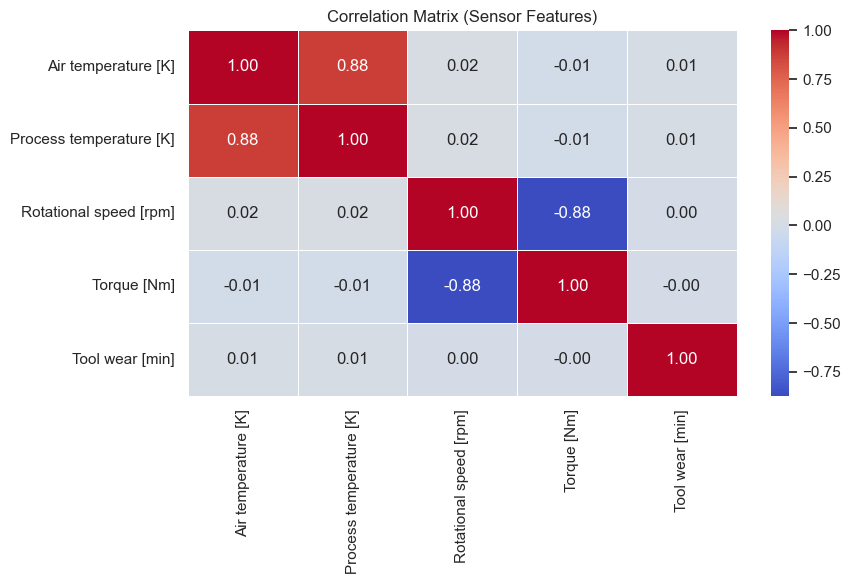

In [29]:
#Correlation analysis on original feature set (not on SMOTE data)

# Correlation matrix ONLY for true numeric sensor features (avoid Type if label-encoded)
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

plt.figure(figsize=(9, 6))
corr_matrix = dataset[sensor_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Sensor Features)")
plt.tight_layout()
plt.show()



In [30]:
#info/preview


X_train_df = pd.DataFrame(X_train, columns=X.columns)

print("X_train info:")
X_train.info()

print("\nX_train head:")
display(X_train.head())



X_train info:
<class 'pandas.core.frame.DataFrame'>
Index: 7000 entries, 1888 to 1424
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     7000 non-null   int64  
 1   Air temperature [K]      7000 non-null   float64
 2   Process temperature [K]  7000 non-null   float64
 3   Rotational speed [rpm]   7000 non-null   float64
 4   Torque [Nm]              7000 non-null   float64
 5   Tool wear [min]          7000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 382.8 KB

X_train head:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
1888,2,297.8,307.4,1900.5,24.3,129
4858,1,303.7,312.3,1349.0,51.0,105
8990,1,297.2,307.9,1493.0,38.4,146
4901,2,303.6,312.3,1630.0,32.4,223
7957,0,300.9,311.9,1900.5,16.5,43


In [31]:
print("X_test info:")
X_test.info()
X_test_df = X_test.copy()


X_test info:
<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 7809 to 7342
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     3000 non-null   int64  
 1   Air temperature [K]      3000 non-null   float64
 2   Process temperature [K]  3000 non-null   float64
 3   Rotational speed [rpm]   3000 non-null   float64
 4   Torque [Nm]              3000 non-null   float64
 5   Tool wear [min]          3000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 164.1 KB


In [32]:
# Create empty lists to store performance metrics

performance_metrics = []


In [33]:
# Initialize models

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "K Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Support Vector Classifier": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Artificial Neural Network": MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        activation="relu",
        solver="adam",
        random_state=42
    )
}


In [34]:
#Training + evaluation loop

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef
)

performance_metrics = []

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    roc_auc = None
    pr_auc = None

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)

    performance_metrics.append({
        "Model": name,
        "Accuracy": accuracy,
        "Balanced Accuracy": bal_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Confusion Matrix": conf_matrix
    })


In [35]:
#Results DataFrame

performance_df = pd.DataFrame(performance_metrics)

# Confusion matrix -> readable format
performance_df["Confusion Matrix"] = performance_df["Confusion Matrix"].apply(lambda x: x.tolist())

# Sort best model first
performance_df = performance_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

performance_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC,PR-AUC,Confusion Matrix
0,Artificial Neural Network,0.967333,0.864856,0.513333,0.754902,0.611111,0.606782,0.959800,0.688902,"[[2825, 73], [25, 77]]"
1,Random Forest,0.965000,0.849460,0.490066,0.725490,0.584980,0.579352,0.974320,0.670398,"[[2821, 77], [28, 74]]"
2,Decision Tree,0.950000,0.841696,0.377551,0.725490,0.496644,0.501190,0.865720,0.455010,"[[2776, 122], [28, 74]]"
3,Support Vector Classifier,0.923333,0.917753,0.296178,0.911765,0.447115,0.494630,0.965013,0.614492,"[[2677, 221], [9, 93]]"
4,K Nearest Neighbors,0.921333,0.803211,0.253676,0.676471,0.368984,0.382752,0.873396,0.285168,"[[2695, 203], [33, 69]]"
5,Naive Bayes,0.798000,0.810315,0.125000,0.823529,0.217054,0.269778,0.898412,0.317841,"[[2310, 588], [18, 84]]"
6,Logistic Regression,0.759000,0.771211,0.102433,0.784314,0.181200,0.224018,0.820211,0.291028,"[[2197, 701], [22, 80]]"


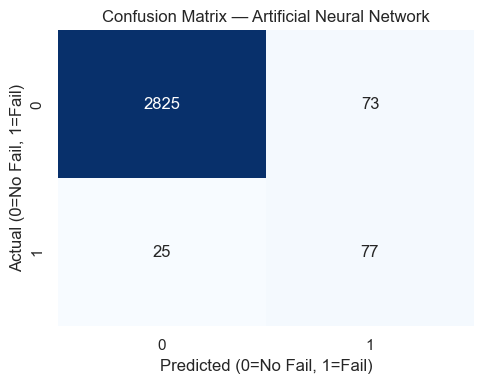

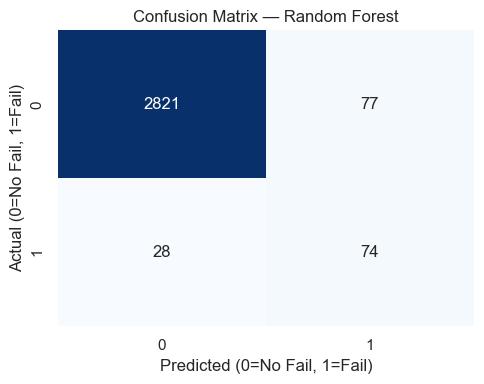

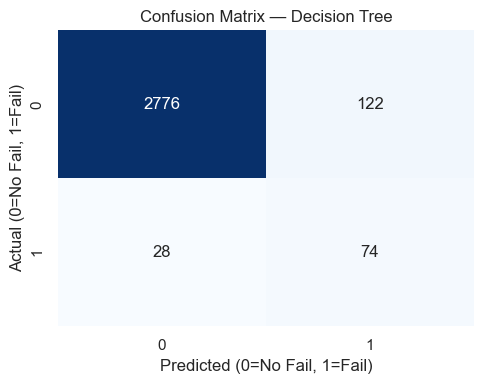

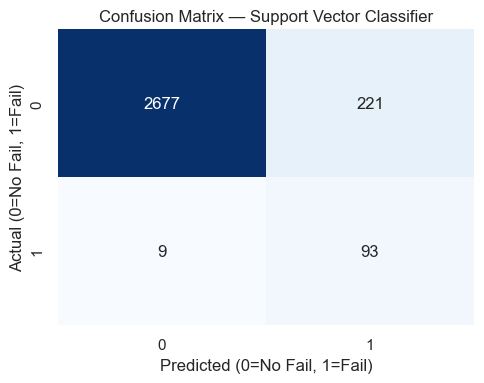

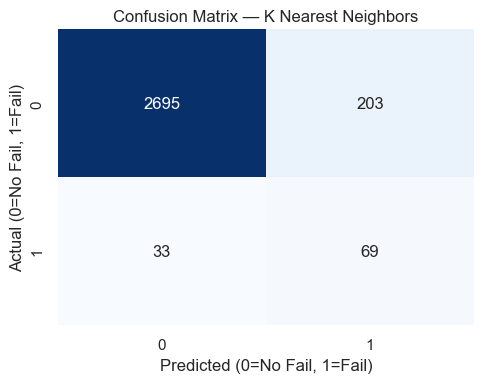

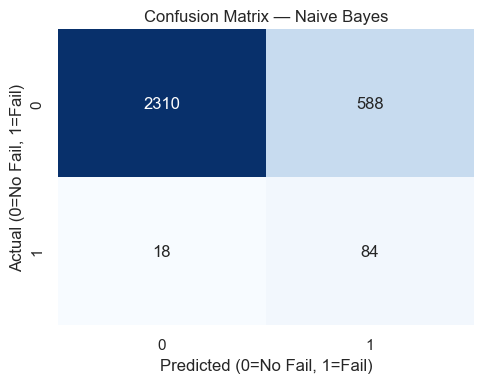

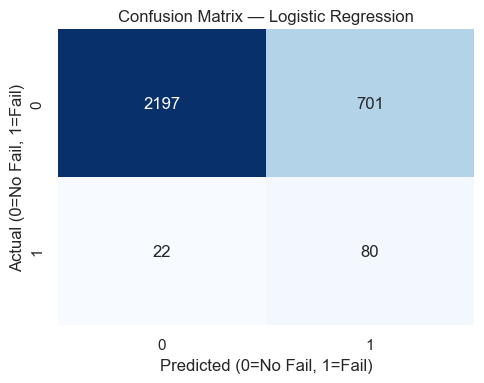

In [36]:
# Plot confusion matrix for each model
for _, row in performance_df.iterrows():
    model_name = row["Model"]
    conf_matrix = np.array(row["Confusion Matrix"])  # ensure numpy array

    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted (0=No Fail, 1=Fail)")
    plt.ylabel("Actual (0=No Fail, 1=Fail)")
    plt.tight_layout()
    plt.show()


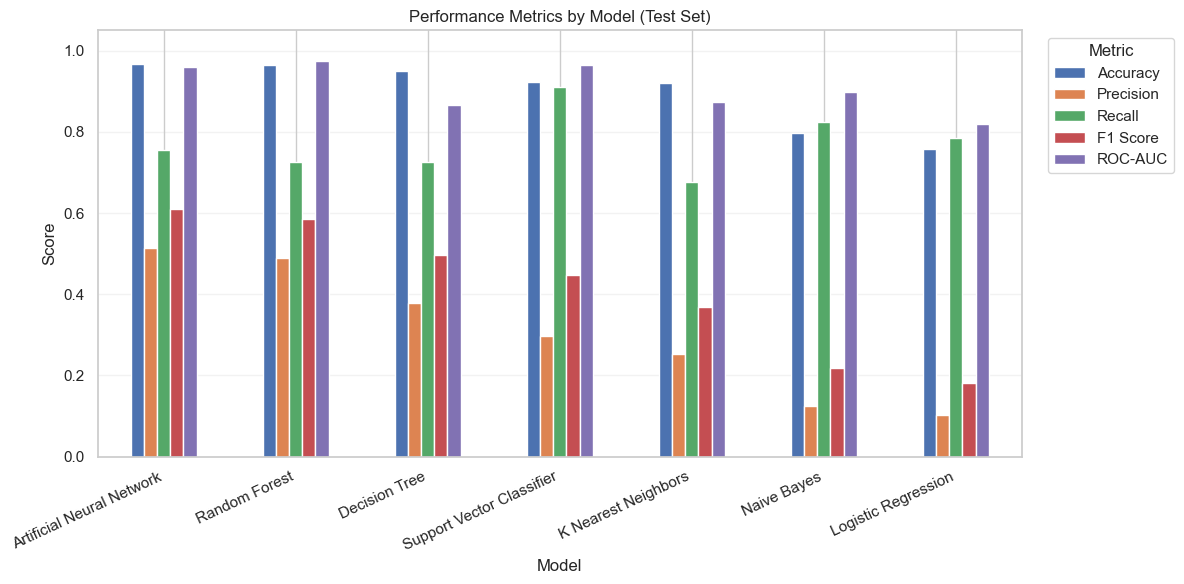

In [37]:
# Plot only numeric metric columns (exclude confusion matrix)

metrics_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
plot_df = performance_df[["Model"] + metrics_cols].copy().set_index("Model")

ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Performance Metrics by Model (Test Set)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [38]:
#Scaling + SMOTE + Model inside an imblearn Pipeline
#RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Pipeline: scaler -> smote -> model (done inside CV folds correctly)
pipe = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

param_dist = {
    "rf__n_estimators": [200, 400, 600],
    "rf__max_depth": [10, 20, 30, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__class_weight": [None, "balanced"]  # useful for imbalance
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=25,
    cv=cv,
    scoring="f1",          # you can also try "average_precision"
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)  # ✅ fit on ORIGINAL train (not SMOTEd)

print("Best parameters:", random_search.best_params_)
best_model = random_search.best_estimator_
print("Best CV F1:", random_search.best_score_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\ACER\Desktop\All Projects\automobile-predictive-failure\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'rf__n_estimators': 600, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': None, 'rf__class_weight': 'balanced'}
Best CV F1: 0.6176977167961564


In [39]:
#Evaluate tuned model

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score, classification_report
)

# Predictions (pipeline handles scaling internally)
y_pred = best_model.predict(X_test)

# Probabilities (if available)
y_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

print("\n--- Tuned Model Evaluation (Test Set) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

if y_prob is not None:
    print(f"\nROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



--- Tuned Model Evaluation (Test Set) ---
Accuracy : 0.9633
Precision: 0.4753
Recall   : 0.7549
F1-Score : 0.5833

Confusion Matrix:
[[2813   85]
 [  25   77]]

ROC-AUC  : 0.9754
PR-AUC   : 0.6791

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2898
           1       0.48      0.75      0.58       102

    accuracy                           0.96      3000
   macro avg       0.73      0.86      0.78      3000
weighted avg       0.97      0.96      0.97      3000



In [40]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_balanced, y_train_balanced)

best_rf = random_search.best_estimator_
print("✅ best_rf created")
print("Best params:", random_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\ACER\Desktop\All Projects\automobile-predictive-failure\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


✅ best_rf created
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'entropy'}


In [41]:
print("X columns:", list(X.columns), "->", len(X.columns))
print("best_rf expects:", best_rf.n_features_in_)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# If scaler was fit on numpy, it won't have feature_names_in_
if hasattr(scaler, "n_features_in_"):
    print("scaler expects:", scaler.n_features_in_)

# What transform is producing RIGHT NOW:
tmp = scaler.transform(X_test)
print("scaler.transform(X_test) shape:", tmp.shape)


X columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'] -> 6
best_rf expects: 6
X_train shape: (7000, 6)
X_test shape: (3000, 6)
scaler expects: 6
scaler.transform(X_test) shape: (3000, 6)


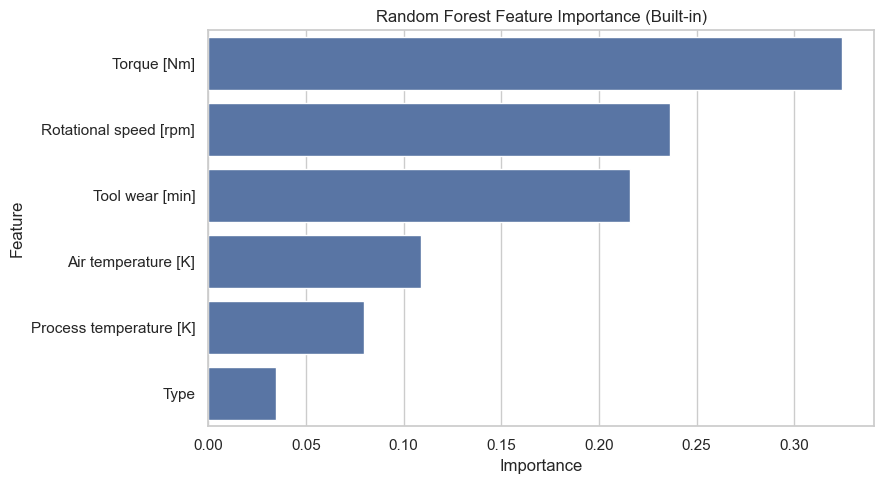

,feature,importance
4,Torque [Nm],0.324651
3,Rotational speed [rpm],0.236190
5,Tool wear [min],0.215929
1,Air temperature [K],0.108878
2,Process temperature [K],0.079888
0,Type,0.034465


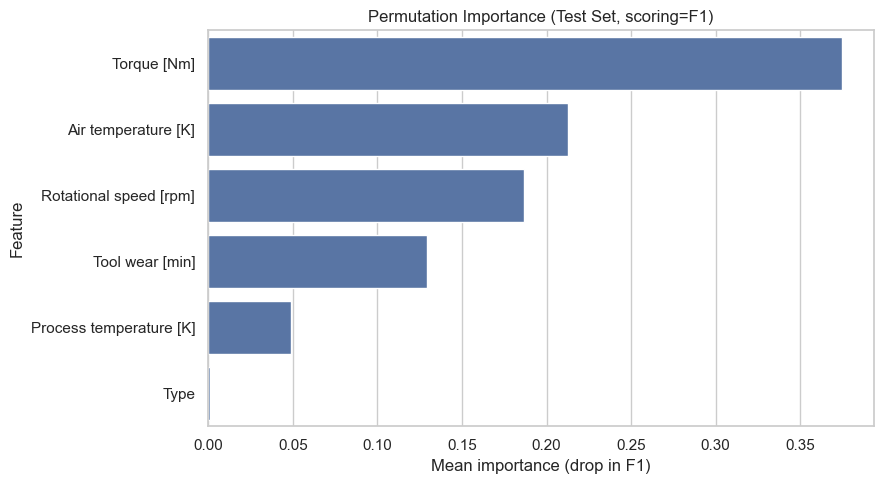

,feature,importance_mean,importance_std
4,Torque [Nm],0.374886,0.026293
1,Air temperature [K],0.212698,0.017923
3,Rotational speed [rpm],0.186488,0.026642
5,Tool wear [min],0.129135,0.009748
2,Process temperature [K],0.048794,0.010365
0,Type,0.001030,0.012557


In [42]:
# Feature Importance
# Works when best_rf was trained on scaled arrays with FEATURES order
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# 1) Built-in RF importance (fast, but can be biased)
rf_imp = pd.DataFrame({
    "feature": FEATURES,  # <-- MUST match the training feature order
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=rf_imp, x="importance", y="feature")
plt.title("Random Forest Feature Importance (Built-in)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(rf_imp)

# 2) Permutation importance (more trustworthy for reporting)
# NOTE: Use the exact test representation you evaluate on (X_test_scaled)
perm = permutation_importance(
    best_rf,
    X_test_scaled,   # same shape/features as used in predict()
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=perm_imp, x="importance_mean", y="feature")
plt.title("Permutation Importance (Test Set, scoring=F1)")
plt.xlabel("Mean importance (drop in F1)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(perm_imp)


In [43]:
# =========================
# DEPLOYMENT / SAVING (Robust)
# =========================
import os, json, joblib
import numpy as np
import pandas as pd
import sklearn

# 0) Lock feature order (IMPORTANT)
# If you already defined FEATURES earlier, keep using that.
FEATURES = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
TARGET_COL = "Target"

# 1) Create artifacts folder
os.makedirs("artifacts", exist_ok=True)

# 2) Save model + scaler
joblib.dump(best_rf, "artifacts/best_rf_model.joblib")
joblib.dump(scaler,  "artifacts/standard_scaler.joblib")
joblib.dump(type_encoder, "artifacts/type_encoder.joblib")
print(" - artifacts/type_encoder.joblib")


# 3) Save metadata as JSON (human-readable)
metadata = {
    "model_name": "Tuned Random Forest (RandomizedSearchCV)",
    "features_order": FEATURES,
    "target": TARGET_COL,
    "preprocessing": {
        "encoding": "LabelEncoder on Type (integer)",
        "scaling": "StandardScaler fit on X_train only",
        "smote": "Applied only on scaled training set",
        "outliers": "IQR capping applied earlier (train bounds recommended)"
    },
    "versions": {
        "python": f"{os.sys.version_info.major}.{os.sys.version_info.minor}.{os.sys.version_info.micro}",
        "sklearn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__
    }
}

with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Saved artifacts:")
print(" - artifacts/best_rf_model.joblib")
print(" - artifacts/standard_scaler.joblib")
print(" - artifacts/metadata.json")

# 4) Inference helper (STRICT)
import joblib
import os
import pandas as pd

def predict_failure_risk(sample_dict, model, scaler, feature_order,
                         type_encoder=None,
                         encoder_path="artifacts/type_encoder.joblib"):
    """
    Works even if Type is raw 'L/M/H' and you forgot to pass type_encoder.
    Returns: (pred_label, failure_probability)
    """

    # ---- Validate keys ----
    missing = [k for k in feature_order if k not in sample_dict]
    extra = [k for k in sample_dict if k not in feature_order]
    if missing:
        raise ValueError(f"Missing required keys: {missing}")
    if extra:
        raise ValueError(f"Unexpected keys provided: {extra}")

    # ---- Build DF in correct order ----
    sample_df = pd.DataFrame([sample_dict], columns=feature_order)

    # ---- Handle Type safely ----
    if "Type" in sample_df.columns:
        # If Type is string like 'L', we must encode
        if sample_df["Type"].dtype == "object" or isinstance(sample_df["Type"].iloc[0], str):
            # Auto-load encoder if not passed
            if type_encoder is None:
                if os.path.exists(encoder_path):
                    type_encoder = joblib.load(encoder_path)
                else:
                    raise ValueError(
                        "Type is categorical (e.g., 'L/M/H') but no type_encoder was provided "
                        "and encoder file was not found."
                    )
            sample_df["Type"] = type_encoder.transform(sample_df["Type"].astype(str))
        else:
            # already numeric
            sample_df["Type"] = pd.to_numeric(sample_df["Type"], errors="raise")

    # ---- Convert remaining columns to numeric ----
    for col in sample_df.columns:
        if col != "Type":
            sample_df[col] = pd.to_numeric(sample_df[col], errors="raise")

    # ---- Scale + predict ----
    sample_scaled = scaler.transform(sample_df)
    pred_label = int(model.predict(sample_scaled)[0])
    pred_prob = float(model.predict_proba(sample_scaled)[0, 1]) if hasattr(model, "predict_proba") else None

    return pred_label, pred_prob



# 5) Better demo: pick a REAL row from dataset (not medians)
# This produces more realistic probabilities.
demo_row = dataset.sample(1, random_state=42).iloc[0]

example_input = {
    "Type": str(demo_row["Type"]),   # raw 'L'
    "Air temperature [K]": float(demo_row["Air temperature [K]"]),
    "Process temperature [K]": float(demo_row["Process temperature [K]"]),
    "Rotational speed [rpm]": float(demo_row["Rotational speed [rpm]"]),
    "Torque [Nm]": float(demo_row["Torque [Nm]"]),
    "Tool wear [min]": float(demo_row["Tool wear [min]"]),
}

type_encoder = joblib.load("artifacts/type_encoder.joblib")

pred, prob = predict_failure_risk(
    sample_dict=example_input,
    model=best_rf,
    scaler=scaler,
    feature_order=FEATURES,
    type_encoder=type_encoder
)

print("Pred:", pred, "| Prob:", prob)



pred, prob = predict_failure_risk(
    sample_dict=example_input,
    model=best_rf,
    scaler=scaler,
    feature_order=FEATURES
)

print("\n🧪 Example Inference (real sampled row):")
print("Input:", example_input)
print("Predicted Failure (0=No, 1=Yes):", pred)
print("Failure Probability:", prob)


 - artifacts/type_encoder.joblib
✅ Saved artifacts:
 - artifacts/best_rf_model.joblib
 - artifacts/standard_scaler.joblib
 - artifacts/metadata.json
Pred: 0 | Prob: 0.049483294483294485

🧪 Example Inference (real sampled row):
Input: {'Type': 'L', 'Air temperature [K]': 300.8, 'Process temperature [K]': 310.3, 'Rotational speed [rpm]': 1538.0, 'Torque [Nm]': 36.1, 'Tool wear [min]': 198.0}
Predicted Failure (0=No, 1=Yes): 0
Failure Probability: 0.049483294483294485


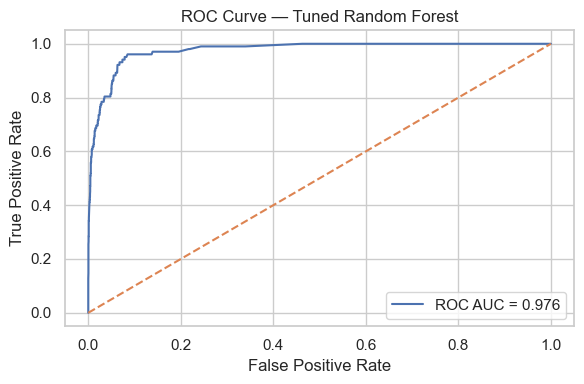

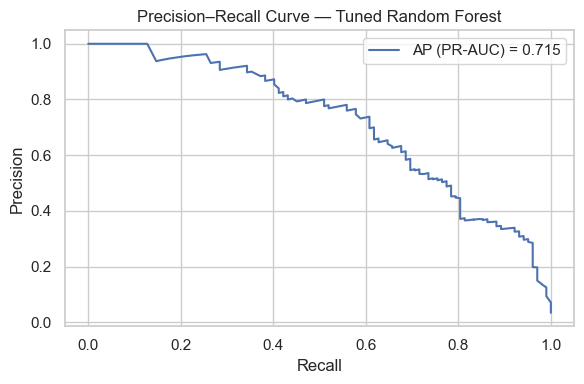

In [44]:
#ROC + PR Curves (best model, test set)

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Probabilities on test set
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(rec, prec, label=f"AP (PR-AUC) = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Tuned Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


In [45]:
#Threshold Tuning

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for th in thresholds:
    y_pred_th = (y_prob >= th).astype(int)
    rows.append({
        "threshold": th,
        "precision": precision_score(y_test, y_pred_th, zero_division=0),
        "recall": recall_score(y_test, y_pred_th, zero_division=0),
        "f1": f1_score(y_test, y_pred_th, zero_division=0)
    })

th_df = pd.DataFrame(rows)
th_df


,threshold,precision,recall,f1
0,0.05,0.182657,0.970588,0.307453
1,0.10,0.234450,0.960784,0.376923
2,0.15,0.280802,0.960784,0.434590
3,0.20,0.309446,0.931373,0.464548
4,0.25,0.343396,0.892157,0.495913
5,0.30,0.370690,0.843137,0.514970
6,0.35,0.384977,0.803922,0.520635
7,0.40,0.422680,0.803922,0.554054
8,0.45,0.467836,0.784314,0.586081
9,0.50,0.506410,0.774510,0.612403


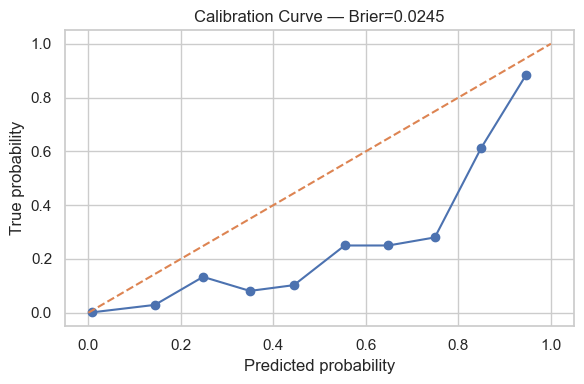

In [46]:
#Calibration Check

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")
brier = brier_score_loss(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title(f"Calibration Curve — Brier={brier:.4f}")
plt.tight_layout()
plt.show()


In [47]:
# Cell 38 — Probabilities + threshold selection + metrics
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss
)

# Predict failure probabilities on test set
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

# Key probability metrics
roc_auc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)      # PR-AUC
brier = brier_score_loss(y_test, y_prob)          # lower is better

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {ap:.4f}")
print(f"Brier : {brier:.4f}")

# Threshold selection: choose threshold that maximizes F1 (simple + defendable)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)

best_idx = int(np.argmax(f1_scores))
best_th = float(thresholds[best_idx])

print(f"\n✅ Best threshold (max F1): {best_th:.4f}")
print(f"Best F1 at this threshold: {float(f1_scores[best_idx]):.4f}")


ROC-AUC: 0.9758
PR-AUC : 0.7146
Brier : 0.0245

✅ Best threshold (max F1): 0.7700
Best F1 at this threshold: 0.6667


In [48]:
# Cell 39 — Error Analysis (False Negatives + False Positives)
import pandas as pd
import numpy as np

X_test_original = X_test.reset_index(drop=True).copy()
y_test_reset = y_test.reset_index(drop=True)

pred_labels = (y_prob >= best_th).astype(int)

results_df = X_test_original.copy()
results_df["y_true"] = y_test_reset
results_df["y_prob"] = y_prob
results_df["y_pred"] = pred_labels

fn = results_df[(results_df["y_true"] == 1) & (results_df["y_pred"] == 0)].sort_values("y_prob")
fp = results_df[(results_df["y_true"] == 0) & (results_df["y_pred"] == 1)].sort_values("y_prob", ascending=False)

print("False Negatives (missed failures):", len(fn))
display(fn.head(10))

print("\nFalse Positives (false alarms):", len(fp))
display(fp.head(10))


False Negatives (missed failures): 40


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],y_true,y_prob,y_pred
2164,1,298.4,309.6,1710.0,27.3,163,1,0.005000,0
1773,2,298.4,308.0,1416.0,38.2,198,1,0.020000,0
2441,1,297.8,308.9,1871.0,25.6,200,1,0.025000,0
1831,2,299.7,309.3,1399.0,41.9,221,1,0.065000,0
2764,1,299.2,310.7,1737.0,27.0,225,1,0.155000,0
2827,1,300.6,310.3,1648.0,30.5,217,1,0.174119,0
1056,0,303.6,312.2,1371.0,54.6,112,1,0.194444,0
2204,2,300.7,309.6,1900.5,19.8,203,1,0.222500,0
1299,1,297.1,308.5,1323.0,44.4,207,1,0.240000,0
496,1,303.4,311.9,1377.0,41.6,34,1,0.240000,0



False Positives (false alarms): 22


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],y_true,y_prob,y_pred
281,1,300.9,310.9,1228.0,66.4,109,0,0.960000,1
2279,1,301.7,310.1,1900.5,12.8,10,0,0.930000,1
1021,2,300.4,309.5,1888.0,21.9,221,0,0.922507,1
2723,1,302.2,310.8,1340.0,47.8,54,0,0.910000,1
2616,1,300.6,309.4,1900.5,13.5,111,0,0.905000,1
2931,1,302.0,310.9,1455.0,43.2,220,0,0.899264,1
2403,1,301.7,310.5,1354.0,50.0,169,0,0.885000,1
53,2,302.2,310.8,1356.0,48.3,36,0,0.880000,1
1029,1,302.2,310.8,1350.0,56.6,76,0,0.879048,1
29,1,300.4,310.0,1282.0,66.1,40,0,0.870000,1


In [49]:
# Cell 40 — Save evaluation report to artifacts/
import os, json
from sklearn.metrics import classification_report, confusion_matrix

os.makedirs("artifacts", exist_ok=True)

report = {
    "best_model": "Tuned Random Forest",
    "threshold_used": float(best_th),
    "roc_auc": float(roc_auc),
    "pr_auc": float(ap),
    "brier_score": float(brier),
    "classification_report": classification_report(
        y_test,
        (y_prob >= best_th).astype(int),
        zero_division=0,
        output_dict=True
    ),
    "confusion_matrix": confusion_matrix(
        y_test,
        (y_prob >= best_th).astype(int)
    ).tolist()
}

with open("artifacts/evaluation_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("✅ Saved artifacts/evaluation_report.json")


✅ Saved artifacts/evaluation_report.json
